# OULAD — Baseline Logistic Regression Model

This notebook trains a leakage-controlled Logistic Regression baseline using the Version 2 weekly student-state dataset.

## Prediction task

At a fixed weekly checkpoint, predict whether a student will ultimately be:

- **At Risk = 1:** `Fail` or `Withdrawn`
- **Not At Risk = 0:** `Pass` or `Distinction`

## Default experimental design

- Prediction checkpoint: **Week 4**
- Split method: **student-grouped train/validation/test split**
- Final baseline: **Logistic Regression with balanced class weights**
- Main decision metric: **Recall and F1-score for the At-Risk class**
- Additional metrics: Accuracy, Balanced Accuracy, ROC-AUC and Confusion Matrix

The notebook deliberately excludes identifiers, final outcomes and future withdrawal information from the feature matrix.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 1. Configuration

The code searches for the Version 2 dataset in Colab, local project folders and `/mnt/data`.

In [2]:
PREDICTION_WEEK = 4
PREDICTION_WEEKS = [4, 8, 12, 16, 20]
TARGET = "at_risk_target"
RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs/baseline_logistic_regression_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    Path("/content/outputs/oulad_weekly_student_states_v2.parquet"),
    Path("/content/outputs/oulad_weekly_student_states_v2.csv.gz"),
    Path("outputs/oulad_weekly_student_states_v2.parquet"),
    Path("outputs/oulad_weekly_student_states_v2.csv.gz"),
    Path("oulad_weekly_student_states_v2.parquet"),
    Path("oulad_weekly_student_states_v2.csv.gz"),
    Path("/mnt/data/oulad_weekly_student_states_v2.parquet"),
    Path("/mnt/data/oulad_weekly_student_states_v2.csv.gz"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Version 2 weekly student-state dataset was not found. "
        "Run Notebook 1 first or update candidate_paths."
    )

print("Dataset:", DATA_PATH)
print("Prediction week:", PREDICTION_WEEK)
print("Prediction weeks for comparison:", PREDICTION_WEEKS)
print(
    "Target:",
    TARGET,
    "= eventual Fail or Withdrawn final_result",
)


Dataset: outputs\oulad_weekly_student_states_v2.parquet
Prediction week: 4
Prediction weeks for comparison: [4, 8, 12, 16, 20]
Target: at_risk_target = eventual Fail or Withdrawn final_result


## 2. Load and validate the weekly-state dataset

In [3]:
if DATA_PATH.suffix == ".parquet":
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH, compression="gzip")

print("Full dataset shape:", df.shape)
print("Week range:", (df["week"].min(), df["week"].max()))
print("Unique students:", df["id_student"].nunique())
print(
    "Student-module-presentation trajectories:",
    df[["id_student", "code_module", "code_presentation"]]
    .drop_duplicates()
    .shape[0],
)

required_columns = {
    "id_student",
    "code_module",
    "code_presentation",
    "week",
    "final_result",
    "at_risk_target",
}

missing_required = required_columns - set(df.columns)
if missing_required:
    raise KeyError(f"Missing required columns: {sorted(missing_required)}")

assert not df.duplicated(
    ["id_student", "code_module", "code_presentation", "week"]
).any(), "Duplicate weekly states detected."

assert set(df[TARGET].dropna().unique()).issubset({0, 1})

print("Basic structural checks passed.")

Full dataset shape: (927471, 48)
Week range: (np.int16(0), np.int16(38))
Unique students: 26358
Student-module-presentation trajectories: 29496
Basic structural checks passed.


## 3. Select one weekly checkpoint

Using one fixed checkpoint avoids placing multiple weeks from the same trajectory into the same baseline sample.

Week 4 provides an early prediction point while still allowing some engagement and assessment evidence to accumulate.

In [4]:
checkpoint = df.loc[df["week"].eq(PREDICTION_WEEK)].copy()

assert not checkpoint.duplicated(
    ["id_student", "code_module", "code_presentation"]
).any()

print("Checkpoint shape:", checkpoint.shape)

target_distribution = (
    checkpoint[TARGET]
    .value_counts(dropna=False)
    .rename_axis("at_risk_target")
    .to_frame("count")
)

target_distribution["percent"] = (
    100
    * target_distribution["count"]
    / target_distribution["count"].sum()
)

display(target_distribution)

Checkpoint shape: (27523, 48)


,count,percent
at_risk_target,,
0,15380,55.880536
1,12143,44.119464


## 4. Define predictor features

### Included feature groups

- Current and cumulative engagement
- Inactivity and regularity
- Assessment progress
- Current academic performance
- Previous attempts and study load
- Student background
- Module identifier

### Excluded fields

- `id_student`
- `final_result`
- `date_unregistration`
- `at_risk_target`
- `withdraw_next_4_weeks`
- Raw dates and cutoffs
- `average_submission_delay` in this initial baseline, because extreme early values still require separate investigation

In [5]:
numeric_features = [
    "weekly_clicks",
    "cumulative_clicks",
    "weekly_active_days",
    "cumulative_active_days",
    "days_since_last_activity",
    "never_active",
    "weekly_active_ratio",
    "cumulative_active_day_ratio",
    "click_regularity",
    "engagement_change",
    "assessments_due_so_far",
    "assessments_submitted_so_far",
    "missed_assessments",
    "late_submission_count",
    "banked_assessment_count",
    "cumulative_grade",
    "weighted_assessment_progress",
    "due_weighted_progress",
    "num_of_prev_attempts",
    "studied_credits",
    "presentation_progress",
    "registration_date_missing",
]

categorical_features = [
    "code_module",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
]

numeric_features = [
    column for column in numeric_features
    if column in checkpoint.columns
]

categorical_features = [
    column for column in categorical_features
    if column in checkpoint.columns
]

feature_columns = numeric_features + categorical_features

leakage_fields = {
    "id_student",
    "final_result",
    "date_unregistration",
    "at_risk_target",
    "withdraw_next_4_weeks",
}

assert not leakage_fields.intersection(feature_columns)

X = checkpoint[feature_columns].copy()
y = checkpoint[TARGET].astype(int)
groups = checkpoint["id_student"]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total predictor columns before encoding:", len(feature_columns))

Numeric features: 22
Categorical features: 7
Total predictor columns before encoding: 29


## 5. Student-grouped train, validation and test split

The same student may appear in more than one OULAD module or presentation.  
Therefore, all records belonging to a student are assigned to only one split.

Approximate proportions:

- Training: 64%
- Validation: 16%
- Test: 20%

In [6]:
outer_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_val_idx, test_idx = next(
    outer_split.split(X, y, groups=groups)
)

X_train_val = X.iloc[train_val_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
groups_train_val = groups.iloc[train_val_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

test_metadata = checkpoint.iloc[test_idx][
    [
        "id_student",
        "code_module",
        "code_presentation",
        "week",
        "final_result",
    ]
].copy()

inner_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_idx, validation_idx = next(
    inner_split.split(
        X_train_val,
        y_train_val,
        groups=groups_train_val,
    )
)

X_train = X_train_val.iloc[train_idx].copy()
y_train = y_train_val.iloc[train_idx].copy()

X_validation = X_train_val.iloc[validation_idx].copy()
y_validation = y_train_val.iloc[validation_idx].copy()

train_students = set(groups_train_val.iloc[train_idx])
validation_students = set(groups_train_val.iloc[validation_idx])
test_students = set(groups.iloc[test_idx])

assert train_students.isdisjoint(validation_students)
assert train_students.isdisjoint(test_students)
assert validation_students.isdisjoint(test_students)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [
        len(X_train),
        len(X_validation),
        len(X_test),
    ],
    "at_risk_rate": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
})

display(split_summary)

,split,rows,at_risk_rate
0,Train,17629,0.442566
1,Validation,4405,0.431101
2,Test,5489,0.444890


## 6. Preprocessing pipeline

- Numeric missing values: median imputation with missingness indicators
- Numeric scaling: standardization
- Categorical missing values: most-frequent imputation
- Categorical encoding: one-hot encoding

In [7]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True,
        ),
    ),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore"),
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

## 7. Compare unweighted and balanced Logistic Regression

This comparison determines whether class weighting improves detection of at-risk students.

In [8]:
def build_model(class_weight):
    return Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def calculate_metrics(
    model_name,
    split_name,
    model,
    X_split,
    y_true,
):
    y_pred = model.predict(X_split)
    y_probability = model.predict_proba(X_split)[:, 1]

    return {
        "model": model_name,
        "split": split_name,
        "rows": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision_at_risk": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall_at_risk": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1_at_risk": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability,
        ),
    }


candidate_models = {
    "Unweighted Logistic Regression": build_model(None),
    "Balanced Logistic Regression": build_model("balanced"),
}

comparison_rows = []

for model_name, candidate_model in candidate_models.items():
    candidate_model.fit(X_train, y_train)

    # Compare candidate models on validation only. The test split is
    # reserved for the final selected baseline evaluation below.
    comparison_rows.append(
        calculate_metrics(
            model_name,
            "Validation",
            candidate_model,
            X_validation,
            y_validation,
        )
    )

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))


,model,split,rows,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,Unweighted Logistic Regression,Validation,4405,0.7385,0.7218,0.7433,0.6008,0.6645,0.7935
1,Balanced Logistic Regression,Validation,4405,0.7299,0.7208,0.6993,0.6551,0.6765,0.7936


## 8. Train the selected baseline

The balanced version is selected because the early-warning use case prioritizes identifying a larger proportion of at-risk students.

In [9]:
baseline_model = build_model("balanced")
baseline_model.fit(X_train, y_train)

validation_prediction = baseline_model.predict(X_validation)
validation_probability = baseline_model.predict_proba(
    X_validation
)[:, 1]

test_prediction = baseline_model.predict(X_test)
test_probability = baseline_model.predict_proba(X_test)[:, 1]

print("Validation classification report")
print(
    classification_report(
        y_validation,
        validation_prediction,
        target_names=[
            "Not At Risk",
            "At Risk",
        ],
        zero_division=0,
    )
)

print("Test classification report")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "Not At Risk",
            "At Risk",
        ],
        zero_division=0,
    )
)

Validation classification report
              precision    recall  f1-score   support

 Not At Risk       0.75      0.79      0.77      2506
     At Risk       0.70      0.66      0.68      1899

    accuracy                           0.73      4405
   macro avg       0.72      0.72      0.72      4405
weighted avg       0.73      0.73      0.73      4405

Test classification report
              precision    recall  f1-score   support

 Not At Risk       0.75      0.79      0.77      3047
     At Risk       0.72      0.68      0.70      2442

    accuracy                           0.74      5489
   macro avg       0.74      0.73      0.73      5489
weighted avg       0.74      0.74      0.74      5489



## 9. Test-set metrics

In [10]:
test_metrics = {
    "prediction_week": PREDICTION_WEEK,
    "test_rows": int(len(y_test)),
    "accuracy": float(
        accuracy_score(y_test, test_prediction)
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(y_test, test_prediction)
    ),
    "precision_at_risk": float(
        precision_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "recall_at_risk": float(
        recall_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "f1_at_risk": float(
        f1_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "roc_auc": float(
        roc_auc_score(y_test, test_probability)
    ),
}

display(
    pd.Series(test_metrics)
    .rename("value")
    .to_frame()
)

,value
prediction_week,4.000000
test_rows,5489.000000
accuracy,0.739661
balanced_accuracy,0.733797
precision_at_risk,0.719169
recall_at_risk,0.680590
f1_at_risk,0.699348
roc_auc,0.813604


## 10. Confusion matrix

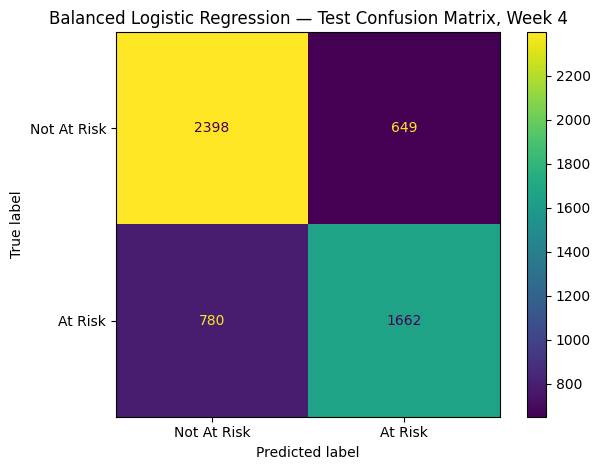

Confusion matrix values: [[2398, 649], [780, 1662]]


In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=[
        "Not At Risk",
        "At Risk",
    ],
)

plt.title(
    "Balanced Logistic Regression — "
    f"Test Confusion Matrix, Week {PREDICTION_WEEK}"
)
plt.tight_layout()
plt.show()

print(
    "Confusion matrix values:",
    confusion_matrix(
        y_test,
        test_prediction,
    ).tolist(),
)

## 11. ROC curve

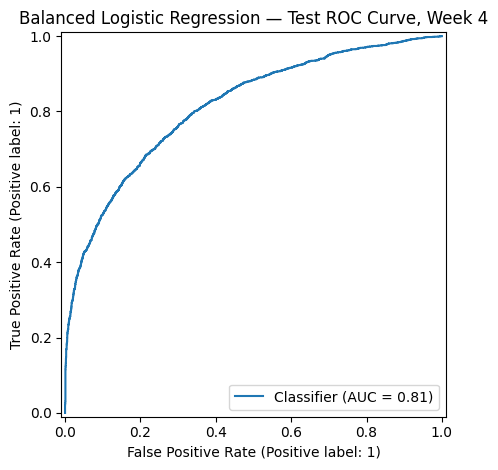

In [12]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
)

plt.title(
    "Balanced Logistic Regression — "
    f"Test ROC Curve, Week {PREDICTION_WEEK}"
)
plt.tight_layout()
plt.show()

## 12. Interpret the strongest model coefficients

A positive coefficient is associated with a higher predicted probability of being at risk.  
A negative coefficient is associated with a lower predicted probability.

These associations are not causal effects.

In [13]:
feature_names = (
    baseline_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    baseline_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    })
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(coefficient_table.head(30))

,feature,coefficient,absolute_coefficient
0,numeric__weekly_active_days,-2.344801,2.344801
1,numeric__weekly_active_ratio,2.245671,2.245671
2,categorical__code_module_GGG,-1.009958,1.009958
3,numeric__missingindicator_cumulative_grade,0.906478,0.906478
4,categorical__code_module_FFF,0.774920,0.774920
5,categorical__code_module_AAA,-0.695401,0.695401
6,numeric__missingindicator_due_weighted_progress,-0.691548,0.691548
7,numeric__cumulative_grade,-0.679148,0.679148
8,numeric__missed_assessments,0.571365,0.571365
9,numeric__due_weighted_progress,0.548293,0.548293


## 13. Save model artifacts and predictions

In [14]:
model_path = (
    OUTPUT_DIR
    / f"balanced_logistic_regression_week_{PREDICTION_WEEK}.joblib"
)

metrics_path = (
    OUTPUT_DIR
    / f"metrics_week_{PREDICTION_WEEK}.json"
)

comparison_path = (
    OUTPUT_DIR
    / f"model_comparison_week_{PREDICTION_WEEK}.csv"
)

predictions_path = (
    OUTPUT_DIR
    / f"test_predictions_week_{PREDICTION_WEEK}.csv"
)

coefficients_path = (
    OUTPUT_DIR
    / f"coefficients_week_{PREDICTION_WEEK}.csv"
)

joblib.dump(baseline_model, model_path)

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        test_metrics,
        file,
        indent=2,
    )

comparison_table.to_csv(
    comparison_path,
    index=False,
)

test_output = test_metadata.reset_index(drop=True)
test_output["actual_at_risk"] = (
    y_test.reset_index(drop=True)
)
test_output["predicted_at_risk"] = (
    test_prediction
)
test_output["at_risk_probability"] = (
    test_probability
)

test_output.to_csv(
    predictions_path,
    index=False,
)

coefficient_table.to_csv(
    coefficients_path,
    index=False,
)

print("Saved model:", model_path.resolve())
print("Saved metrics:", metrics_path.resolve())
print("Saved comparison:", comparison_path.resolve())
print("Saved predictions:", predictions_path.resolve())
print("Saved coefficients:", coefficients_path.resolve())

Saved model: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\balanced_logistic_regression_week_4.joblib
Saved metrics: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\metrics_week_4.json
Saved comparison: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\model_comparison_week_4.csv
Saved predictions: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\test_predictions_week_4.csv
Saved coefficients: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\coefficients_week_4.csv


## 14. Multi-week baseline comparison

Evaluate the same balanced Logistic Regression baseline at several weekly checkpoints. Earlier weeks are more useful for intervention, while later weeks usually have more evidence and may produce stronger metrics.


In [15]:
def evaluate_prediction_week(prediction_week):
    week_checkpoint = df.loc[
        df["week"].eq(prediction_week)
    ].copy()

    if week_checkpoint.empty:
        return None

    week_numeric_features = [
        column for column in numeric_features
        if column in week_checkpoint.columns
    ]

    week_categorical_features = [
        column for column in categorical_features
        if column in week_checkpoint.columns
    ]

    week_feature_columns = (
        week_numeric_features + week_categorical_features
    )

    X_week = week_checkpoint[week_feature_columns].copy()
    y_week = week_checkpoint[TARGET].astype(int)
    groups_week = week_checkpoint["id_student"]

    outer_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )

    train_val_idx, test_idx = next(
        outer_split.split(X_week, y_week, groups=groups_week)
    )

    X_train_val_week = X_week.iloc[train_val_idx].copy()
    y_train_val_week = y_week.iloc[train_val_idx].copy()
    groups_train_val_week = groups_week.iloc[train_val_idx].copy()

    X_test_week = X_week.iloc[test_idx].copy()
    y_test_week = y_week.iloc[test_idx].copy()

    inner_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )

    train_idx, validation_idx = next(
        inner_split.split(
            X_train_val_week,
            y_train_val_week,
            groups=groups_train_val_week,
        )
    )

    X_train_week = X_train_val_week.iloc[train_idx].copy()
    y_train_week = y_train_val_week.iloc[train_idx].copy()

    X_validation_week = X_train_val_week.iloc[
        validation_idx
    ].copy()
    y_validation_week = y_train_val_week.iloc[
        validation_idx
    ].copy()

    week_preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            week_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            week_categorical_features,
        ),
    ])

    week_model = Pipeline([
        ("preprocessor", week_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ])

    week_model.fit(X_train_week, y_train_week)

    validation_metrics = calculate_metrics(
        "Balanced Logistic Regression",
        "Validation",
        week_model,
        X_validation_week,
        y_validation_week,
    )

    test_metrics_week = calculate_metrics(
        "Balanced Logistic Regression",
        "Test",
        week_model,
        X_test_week,
        y_test_week,
    )

    rows = []
    for metrics in [validation_metrics, test_metrics_week]:
        metrics = metrics.copy()
        metrics["prediction_week"] = prediction_week
        metrics["at_risk_rate"] = y_week.mean()
        rows.append(metrics)

    return rows


multi_week_rows = []

for prediction_week in PREDICTION_WEEKS:
    week_rows = evaluate_prediction_week(prediction_week)
    if week_rows is not None:
        multi_week_rows.extend(week_rows)

multi_week_results = pd.DataFrame(multi_week_rows)

ordered_columns = [
    "prediction_week",
    "split",
    "rows",
    "at_risk_rate",
    "accuracy",
    "balanced_accuracy",
    "precision_at_risk",
    "recall_at_risk",
    "f1_at_risk",
    "roc_auc",
]

multi_week_results = multi_week_results[ordered_columns]

split_order = {
    "Validation": 0,
    "Test": 1,
}

multi_week_display = multi_week_results.assign(
    split_order=multi_week_results["split"].map(split_order)
)

display(
    multi_week_display
    .sort_values(["prediction_week", "split_order"])
    .drop(columns="split_order")
    .round(4)
)


,prediction_week,split,rows,at_risk_rate,accuracy,balanced_accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,4,Validation,4405,0.4412,0.7299,0.7208,0.6993,0.6551,0.6765,0.7936
1,4,Test,5489,0.4412,0.7397,0.7338,0.7192,0.6806,0.6993,0.8136
2,8,Validation,4241,0.4199,0.7458,0.7343,0.6982,0.6701,0.6839,0.8219
3,8,Test,5308,0.4199,0.7751,0.7681,0.7434,0.7210,0.7320,0.8436
4,12,Validation,4083,0.4019,0.7894,0.7803,0.7448,0.7322,0.7384,0.8634
5,12,Test,5125,0.4019,0.7885,0.7794,0.7433,0.7311,0.7371,0.8630
6,16,Validation,4022,0.3829,0.8240,0.8138,0.7588,0.7740,0.7663,0.8914
7,16,Test,4989,0.3829,0.8162,0.8039,0.7715,0.7488,0.7600,0.8890
8,20,Validation,3878,0.3666,0.8445,0.8335,0.7709,0.7962,0.7833,0.9113
9,20,Test,4865,0.3666,0.8368,0.8265,0.7841,0.7841,0.7841,0.9050


## 15. Save multi-week comparison


In [16]:
multi_week_path = (
    OUTPUT_DIR / "multi_week_comparison.csv"
)

multi_week_results.to_csv(
    multi_week_path,
    index=False,
)

print("Saved multi-week comparison:", multi_week_path.resolve())


Saved multi-week comparison: G:\Queen's\Graduation Project\Digital Twin Notebooks\outputs\baseline_logistic_regression_v2\multi_week_comparison.csv


## Baseline interpretation

This baseline predicts whether a student will eventually finish with `Fail` or `Withdrawn` from their week-4 state. It is an early-warning reference target, not a direct four-week withdrawal target.

The candidate Logistic Regression variants are compared on the validation split only. The test split is reserved for the final selected baseline evaluation.

The baseline should be reported as an initial reference model rather than the final predictive system. The multi-week comparison should be used to justify the selected early-warning checkpoint.

The next experimental steps are:

1. Select the best early-warning checkpoint based on the multi-week comparison.
2. Test presentation-aware temporal generalization.
3. Compare Logistic Regression with tree-based models.
4. Evaluate probability calibration.
5. Tune the decision threshold if recall is more important than false alarms.
6. Perform fairness analysis across demographic groups.
7. Add explainability after the baseline is validated.
